# 06 — EDA Blocco 2: Profilo demografico delle vittime

**Fase PACE**: Analyze  
**Obiettivo**: analizzare il profilo demografico delle vittime (sesso, età, etnia) 
a livello aggregato, per tipo di crimine e per area LAPD. Focus specifico 
sulle vittime anziane (65+).

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q2.1 — Distribuzione vittime per sesso, età, etnia (integrato per area LAPD)
- Q2.2 — Profilo vittime incrociato con tipologie di crimine
- Q2.3 — Focus vittime anziane (65+): tipologie di reato e aree

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_row', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')

df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q2.1 — Distribuzione vittime per sesso, età ed etnia

Analizziamo la distribuzione demografica delle vittime sull'intero dataset. 
Per ciascuna dimensione (sesso, età, etnia) produciamo prima una visualizzazione 
aggregata, poi integriamo per area LAPD per identificare differenze territoriali.

In [4]:
q21_df = df[['AREA NAME', 'Vict Age', 'Vict Sex', 'Vict Descent']].copy()

demo_dist_df = (
    q21_df
    .groupby('Vict Sex', as_index = False)
    .agg(count = ('Vict Sex', 'count'))
)

print(demo_dist_df.head())

  Vict Sex    count
0        F  1230565
1        M  1359841
2        X   489018


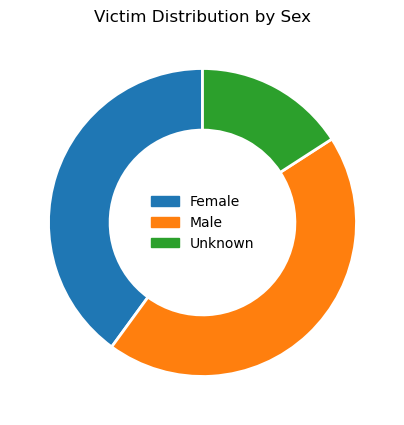

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts = ax.pie(
    x=demo_dist_df['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'},
    startangle=90
)

# Legenda interna con barra colorata - etichetta
sex_labels = {
    'F': 'Female',
    'M': 'Male',
    'X': 'Unknown'
}

labels = [sex_labels.get(s, s) for s in demo_dist_df['Vict Sex'].tolist()]
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=wedges[i].get_facecolor(), label=labels[i])
    for i in range(len(wedges))
]
ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=10
)

ax.set_title('Victim Distribution by Sex')

plt.savefig('../../outputs/06_eda_block2/08_donut_victim_sex.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q2.1 — Distribuzione per sesso

- **Maschi** (44.2%, 1.359.841): categoria più rappresentata, ma con un margine 
  contenuto rispetto alle femmine.
- **Femmine** (40.0%, 1.230.565): gap di soli 4 punti percentuali rispetto ai 
  maschi. Distribuzione più equilibrata di quanto ci si potrebbe aspettare, 
  probabilmente perché il dataset include tutti i tipi di crimine, inclusi 
  quelli domestici dove le donne sono sovrarappresentate come vittime.
- **Sconosciuto** (15.9%, 489.018): quota significativa, composta principalmente 
  da crimini senza vittima diretta identificabile (furti di veicoli, vandalismi) 
  dove il sesso non viene registrato.

**Nota**: la sovrarappresentazione maschile tipica della letteratura criminologica 
(violenza pubblica) risulta attenuata in questo dataset aggregato. La separazione 
per tipo di crimine nel Blocco 3 (reati domestici) mostrerà con più chiarezza 
le differenze di genere per categoria specifica.